## (0) Settings and Functions

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [13]:
df = pd.read_csv("../../data/treated/play_store_reviews_treated.csv")

df['CLEAN_TEXT'] = (
    df['CLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(3010, 4)


,UNCLEAN_TEXT,SENTIMENT,EMOTION,CLEAN_TEXT
0,app shope razoá apes fácil utiliz apresent alg...,positive,sadness,app shope razoa apes facil utiliz apresent alg...
1,app bem otimiz fácil visual produt ped rastrei...,positive,sadness,app bem otimiz facil visual produt ped rastrar...
2,app bom prát fácil entend porém algum vend man...,positive,sadness,app bom prat facil entend porem algum vend man...


In [14]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_weighted': 'f1_weighted',
        'precision_weighted': 'precision_weighted',
        'recall_weighted': 'recall_weighted'
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
        n_jobs=-1
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_weighted']
    recall_scores  = results['test_recall_weighted']
    f1_scores = results['test_f1_weighted']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_weighted": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_weighted":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_weighted":   (f1_scores.mean(),   f1_scores.std(),   f1_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_weighted'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

## (1) Predict Emotion

In [15]:
X_text = df['CLEAN_TEXT']

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(2107,) (451,) (452,)



Running model: LogisticRegression


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=

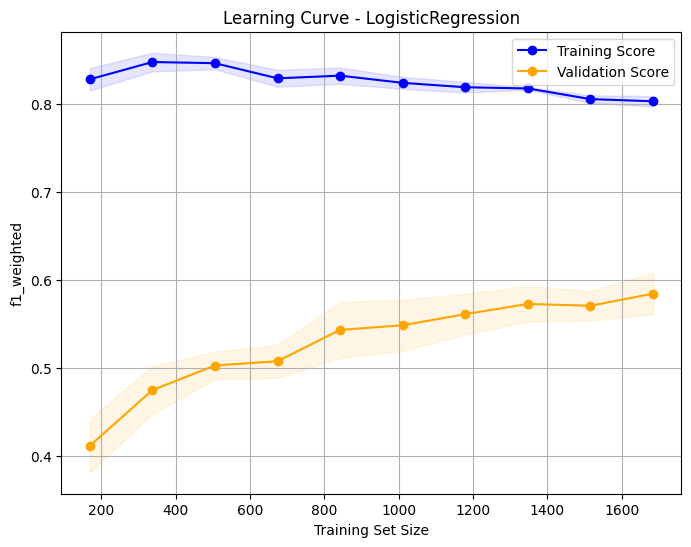


Running model: RidgeClassifier


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=

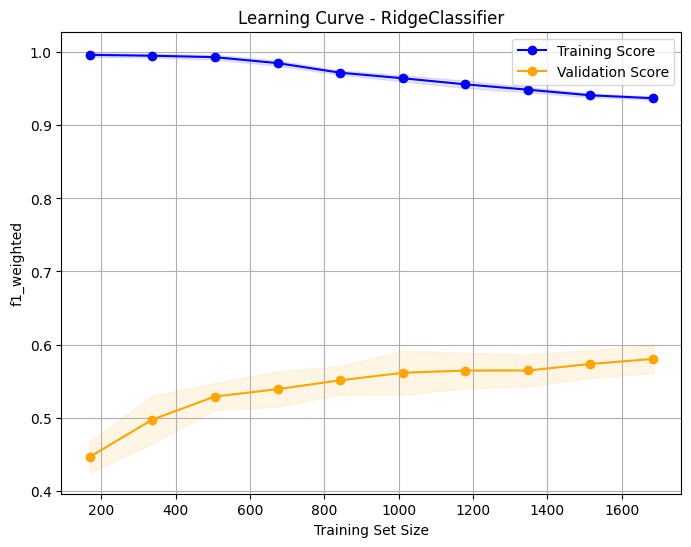


Running model: LinearSVC


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=

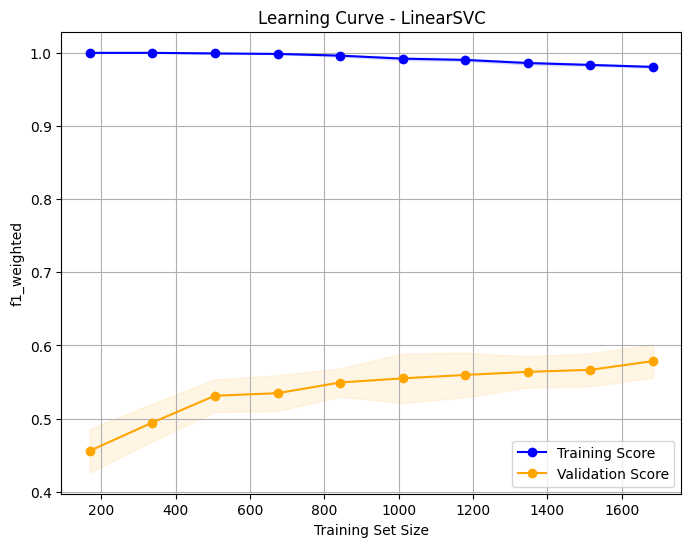


Running model: RandomForest


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=

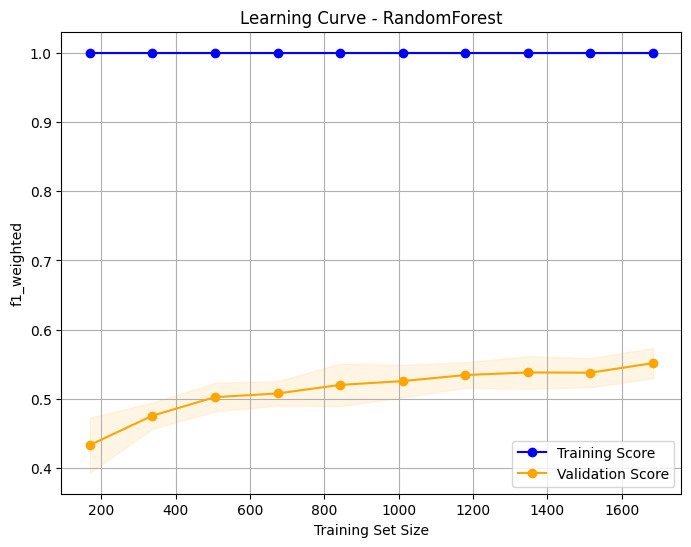


Running model: XGBClassifier


c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=

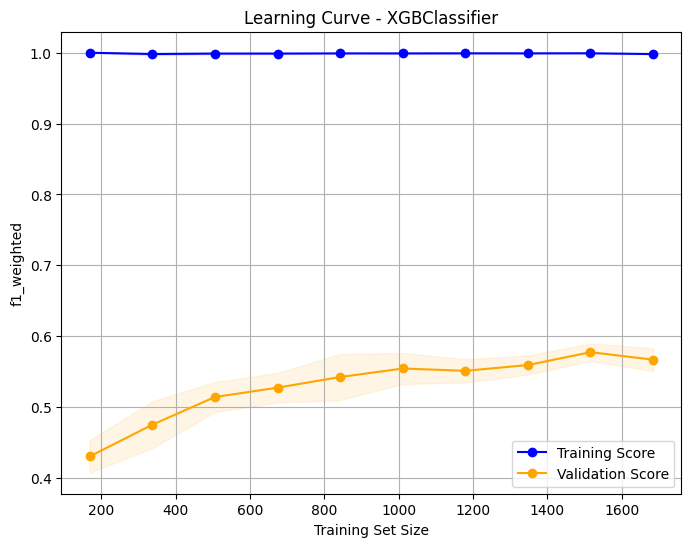

Best model: XGBClassifier


In [16]:
models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("model", model)
    ])

    cv_res = avaliar_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_weighted")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_weighted_mean":  cv_res["Precision_weighted"][0],
        "CV_Precision_weighted_std":   cv_res["Precision_weighted"][1],
        "CV_Precision_weighted_all":   cv_res["Precision_weighted"][2],

        "CV_Recall_weighted_mean":  cv_res["Recall_weighted"][0],
        "CV_Recall_weighted_std":   cv_res["Recall_weighted"][1],
        "CV_Recall_weighted_all":   cv_res["Recall_weighted"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_weighted_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [17]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_weighted", "Recall_weighted", "F1_weighted"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_weighted", "Recall_weighted", "F1_weighted"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/baseline/baseline_08_PlayStoreReviews_TFIDF.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
LogisticRegression,0.5962 ± 0.0259,0.5853 ± 0.024,0.5962 ± 0.0259,0.5724 ± 0.0252
RidgeClassifier,0.5874 ± 0.0269,0.5689 ± 0.027,0.5874 ± 0.0269,0.5718 ± 0.0261
LinearSVC,0.5847 ± 0.0237,0.5712 ± 0.0266,0.5847 ± 0.0237,0.5717 ± 0.0233
RandomForest,0.5765 ± 0.0194,0.5791 ± 0.0266,0.5765 ± 0.0194,0.5433 ± 0.0189
XGBClassifier,0.5868 ± 0.0199,0.5816 ± 0.0252,0.5868 ± 0.0199,0.5739 ± 0.0204


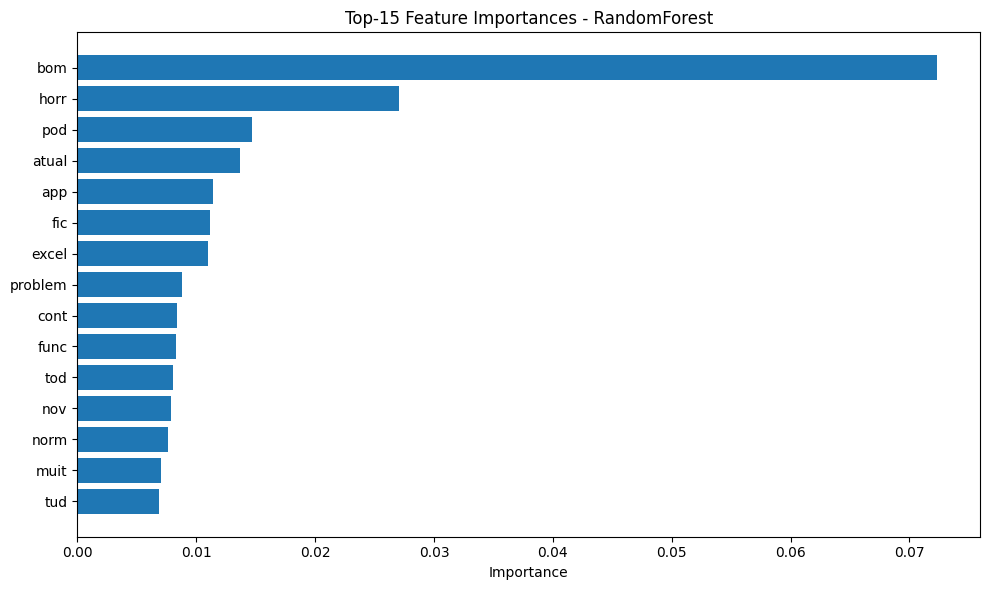

In [18]:
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["tfidf"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")

## (2) Predict Sentiment

In [19]:
X_text = df['CLEAN_TEXT']

le = LabelEncoder()
y = le.fit_transform(df['SENTIMENT'])

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
    stratify=y
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
    stratify=y_aux
)

print(X_text_train.shape, X_text_dev.shape, X_text_test.shape)

(2107,) (451,) (452,)



Running model: LogisticRegression


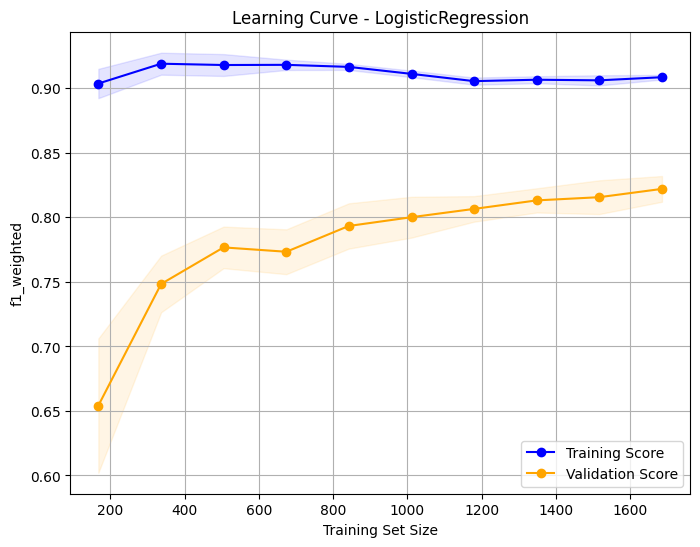


Running model: RidgeClassifier


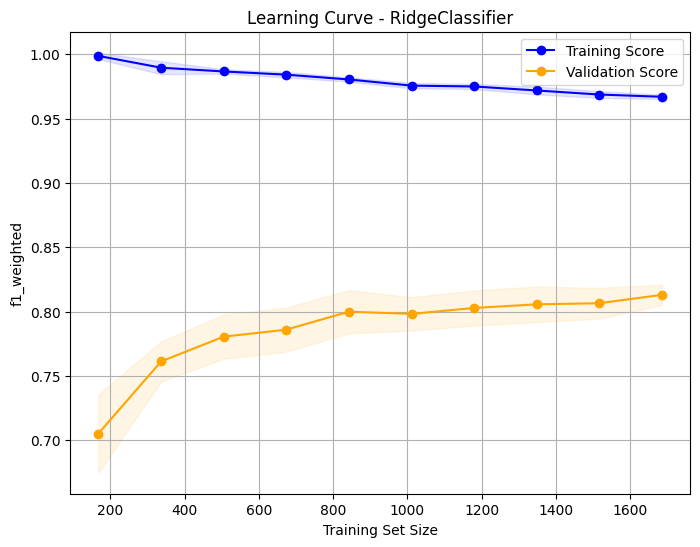


Running model: LinearSVC


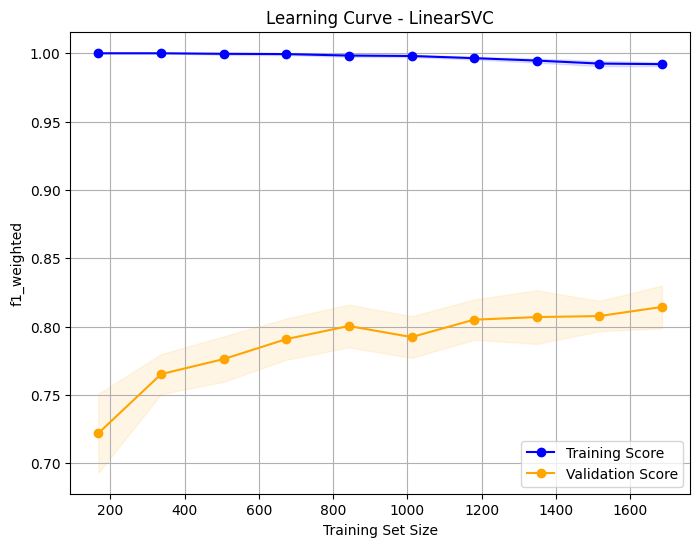


Running model: RandomForest


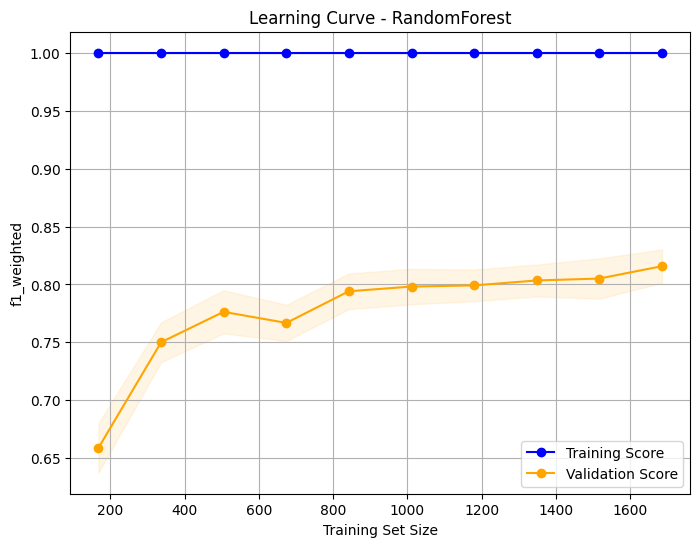


Running model: XGBClassifier


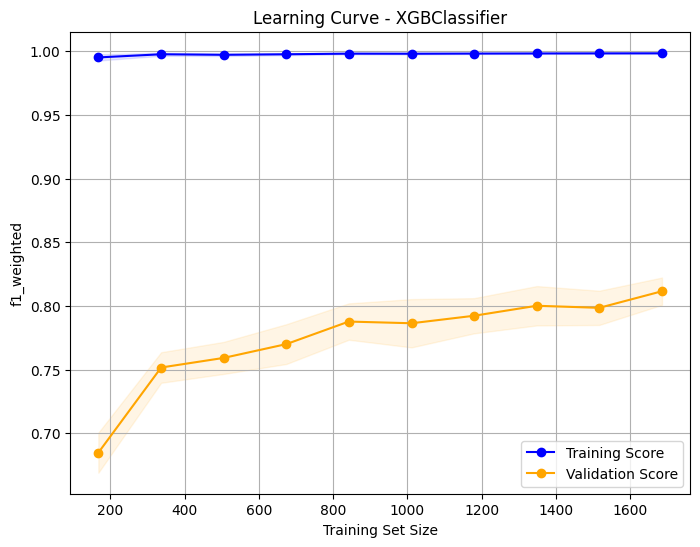

Best model: LogisticRegression


In [20]:
models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("model", model)
    ])

    cv_res = avaliar_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_weighted")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_weighted_mean":  cv_res["Precision_weighted"][0],
        "CV_Precision_weighted_std":   cv_res["Precision_weighted"][1],
        "CV_Precision_weighted_all":   cv_res["Precision_weighted"][2],

        "CV_Recall_weighted_mean":  cv_res["Recall_weighted"][0],
        "CV_Recall_weighted_std":   cv_res["Recall_weighted"][1],
        "CV_Recall_weighted_all":   cv_res["Recall_weighted"][2],

        "CV_F1_weighted_mean":  cv_res["F1_weighted"][0],
        "CV_F1_weighted_std":   cv_res["F1_weighted"][1],
        "CV_F1_weighted_all":   cv_res["F1_weighted"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_weighted_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [21]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_weighted", "Recall_weighted", "F1_weighted"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_weighted", "Recall_weighted", "F1_weighted"]
    return formatted_df[cols]

# df_results.to_csv("../../data/out/baseline/baseline_08_PlayStoreReviews_TFIDF.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
LogisticRegression,0.834 ± 0.0149,0.8123 ± 0.0147,0.834 ± 0.0149,0.8212 ± 0.0154
RidgeClassifier,0.8227 ± 0.0165,0.8004 ± 0.0165,0.8227 ± 0.0165,0.8104 ± 0.0168
LinearSVC,0.8212 ± 0.0164,0.8039 ± 0.0183,0.8212 ± 0.0164,0.8102 ± 0.0164
RandomForest,0.8239 ± 0.0118,0.8078 ± 0.0171,0.8239 ± 0.0118,0.8121 ± 0.0122
XGBClassifier,0.8173 ± 0.0162,0.8121 ± 0.0177,0.8173 ± 0.0162,0.8107 ± 0.0163


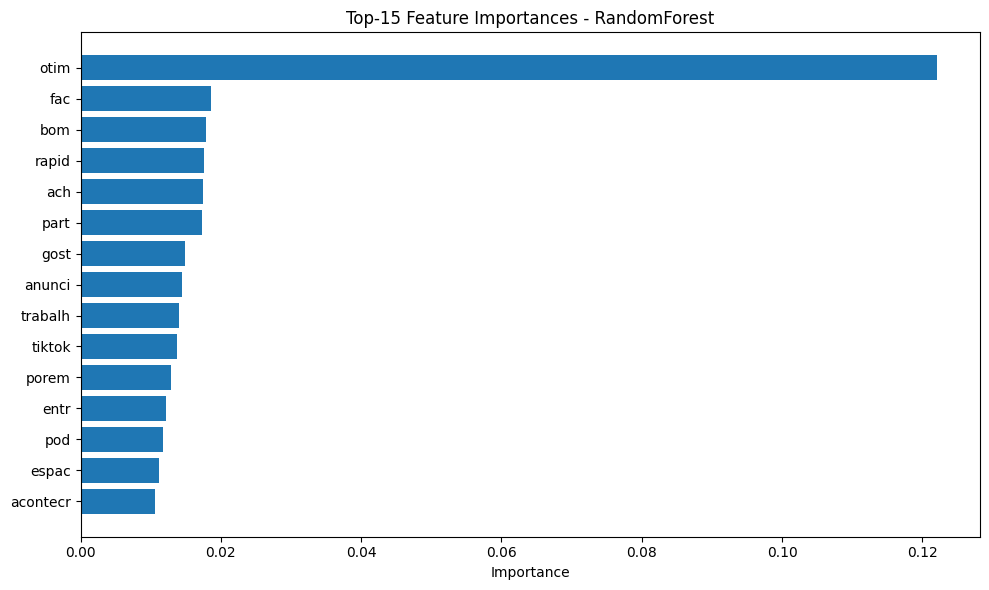

In [22]:
pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["tfidf"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")